# README #
Gliederung und wie das workbook zu nutzen ist

In [58]:
#Imports
import sqlite3
import time

import plotly.graph_objects as go
import plotly.express as px
import matplotlib.pyplot as plt
from IPython.display import clear_output

import math
import pandas as pd
import numpy as np
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from scipy.spatial.transform import Rotation
import matplotlib.cm as cm
import matplotlib.patches as mpatches
from scipy.stats import gaussian_kde

rng = np.random.default_rng()

In [59]:
#Data import

PATH_TO_CSV = "../data/raw_files/R1_pickup_export_20260616_141816.csv"

input_df = pd.read_csv(PATH_TO_CSV)

#IMU
imu_df = input_df[input_df["source"] == "imu"][["timestamp_ms", "id", "x", "y", "z"]].copy()
imu_df.columns = ["timestamp_ms", "sensor", "x", "y", "z"]
imu_df["timestamp_ms"] = imu_df["timestamp_ms"].astype("int64")
imu_df.reset_index(drop=True)

#BLE RSSI
ble_df = input_df[input_df["source"] == "ble_rssi"][["timestamp_ms", "id", "address", "rssi"]].copy()
ble_df.columns = ["timestamp_ms", "beacon_name", "address", "rssi"]
ble_df["timestamp_ms"] = ble_df["timestamp_ms"].astype("int64")

#Beacon Position px
BEACON_DATA = [
    ("arrive_emi1", 370.0, 47.0, 1),
    ("arrive_emi2", 445.0, 40.0, 1),
    ("arrive_emi3", 588.0, 20.0, 1),
    ("arrive_emi4", 590.0, 20.0, 0),
    ("arrive_emi8", 370.0, 50.0, 0),
    ("arrive_emi10", 510.0, 40.0, 0),
]
#Door Position px
DOOR_POSITIONS = [
    ("H01",   600, 60, 0),
    ("H02",   587, 31, 0),
    ("H03",   396, 30, 0),
    ("T016",  626, 17, 0),
    ("T021",  508, 22, 0),
    ("T022",  475, 22, 0),
    ("H11",   600, 60, 1),
    ("H12",   587, 31, 1),
    ("H13",   396, 30, 1),
    ("T109c", 480, 40, 1),
    ("T125",  325, 33, 1),
]

# Step Detection & Heading
evtl orientierung an forlesung als quelle

In [60]:
# Imu_DF nach Sensor
accel_df = imu_df[imu_df["sensor"] == "accel"][["timestamp_ms", "x", "y", "z"]].sort_values("timestamp_ms").reset_index(drop=True)
gyro_df = imu_df[imu_df["sensor"] == "gyro"][["timestamp_ms", "x", "y", "z"]].sort_values("timestamp_ms").reset_index(drop=True)
mag_df = imu_df[imu_df["sensor"] == "mag"][["timestamp_ms", "x", "y", "z"]].sort_values("timestamp_ms").reset_index(drop=True)
imu_processed_df = imu_df[imu_df["sensor"] == "imu_processed"][["timestamp_ms", "x", "y", "z"]].sort_values("timestamp_ms").reset_index(drop=True)

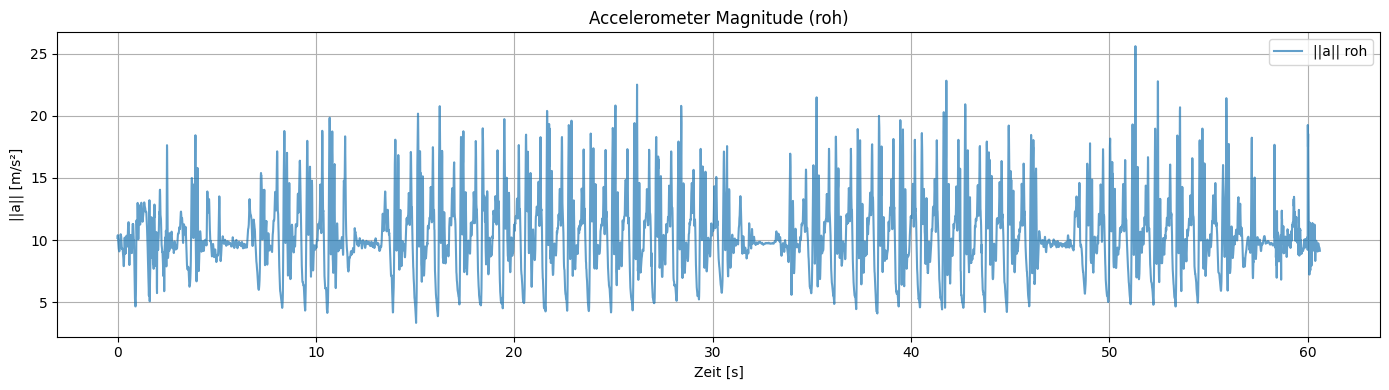

In [61]:
# Norm berechnen
accel_df['norm'] = np.sqrt(accel_df['x']**2 + accel_df['y']**2 + accel_df['z']**2)
accel_df['time_s'] = (accel_df['timestamp_ms'] - accel_df['timestamp_ms'].min()) / 1000
fs = 1000/accel_df['timestamp_ms'].diff().median()

plt.figure(figsize=(14, 4))
plt.plot(accel_df['time_s'], accel_df['norm'], alpha=0.7, label='||a|| roh')
plt.title(f'Accelerometer Magnitude (roh)')
plt.xlabel('Zeit [s]')
plt.ylabel('||a|| [m/s²]')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

MA window = 12 samples (100 ms)


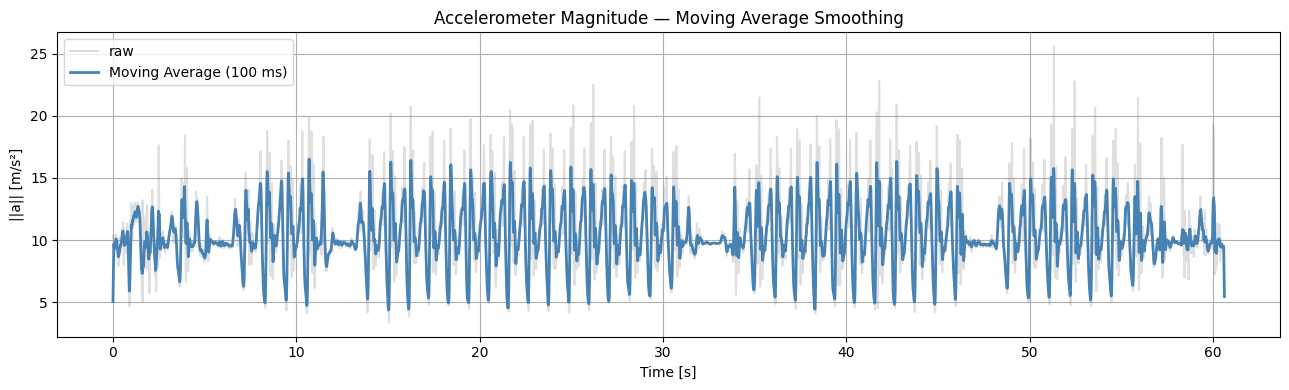

In [62]:
# ── Moving Average via numpy convolution (no scipy) ───────────
MA_WINDOW_MS = 100    # Moving Average window length in ms
THRESHOLD_K  = 0.5    # dynamic threshold: mean + K * std
MIN_STEP_MS  = 300    # physiological minimum between steps [ms]

window = max(1, int((MA_WINDOW_MS / 1000) * fs))
kernel = np.ones(window) / window
accel_df['norm_ma'] = np.convolve(accel_df['norm'].values, kernel, mode='same')
print(f'MA window = {window} samples ({MA_WINDOW_MS} ms)')

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(accel_df['time_s'], accel_df['norm'], alpha=0.25, color='gray', label='raw')
ax.plot(accel_df['time_s'], accel_df['norm_ma'], color='steelblue', linewidth=2,
        label=f'Moving Average ({MA_WINDOW_MS} ms)')
ax.set_title(f'Accelerometer Magnitude — Moving Average Smoothing')
ax.set_xlabel('Time [s]')
ax.set_ylabel('||a|| [m/s²]')
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()

In [63]:
#ADF + KPSS

sig = accel_df['norm_ma'].dropna()

adf_stat, adf_p, *_ = adfuller(sig)
kpss_stat, kpss_p, *_ = kpss(sig, regression='c', nlags='auto')

stationary = (adf_p < 0.05) and (kpss_p > 0.05)

if not stationary:
    accel_df['signal_det'] = accel_df['norm_ma'].diff()
    decision = '1st-order differencing applied'
else:
    accel_df['signal_det'] = accel_df['norm_ma']
    decision = 'signal used directly'

print(f'ADF p={adf_p:.4f} | KPSS p={kpss_p:.4f} | → {decision}')
print(f'ADF p: {round(adf_p,  4)}')
print(f'KPSS p: {round(kpss_p, 4)}')
print(f'Stationary:  {stationary}')
print(f'Decision: {decision}')

ADF p=0.0000 | KPSS p=0.1000 | → signal used directly
ADF p: 0.0
KPSS p: 0.1
Stationary:  True
Decision: signal used directly


/var/folders/bs/nw8kkx7506l7ph_wg5ljh3m80000gp/T/ipykernel_13891/4235370792.py:6: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(sig, regression='c', nlags='auto')


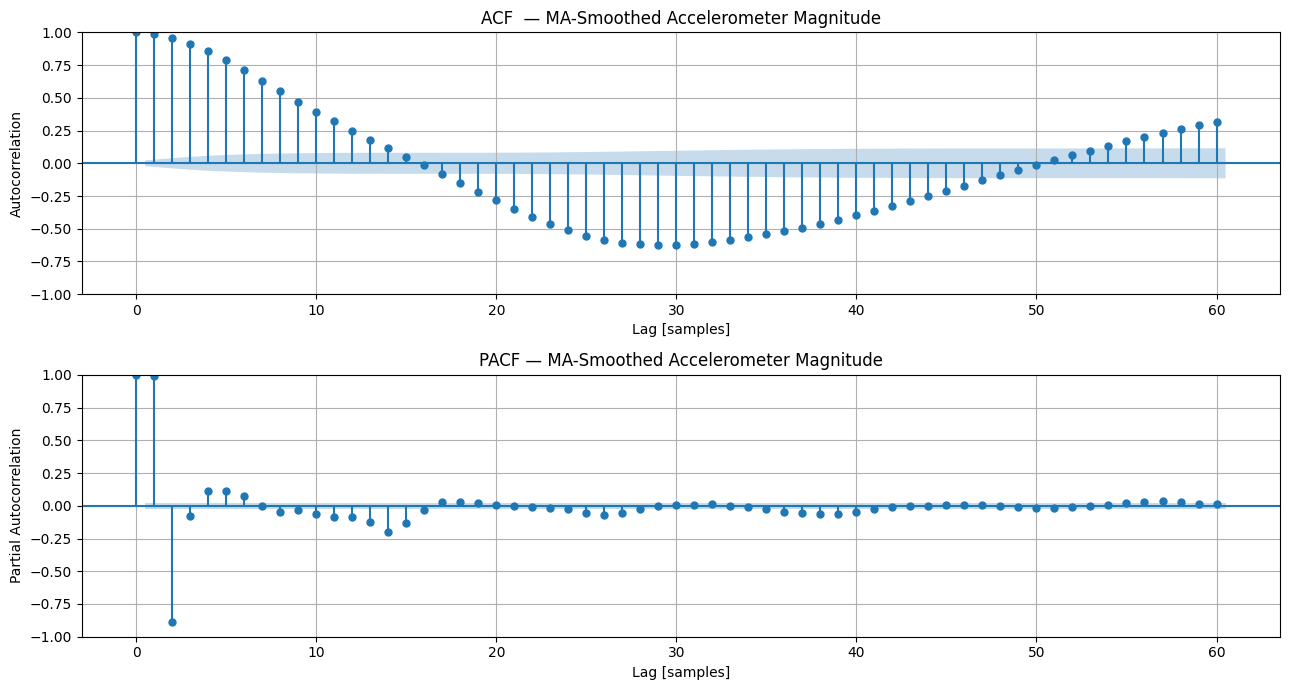

In [64]:
#ACD / PACF

sig = accel_df['signal_det'].dropna()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 7))
plot_acf( sig, lags=60, ax=ax1,
          title=f'ACF  — MA-Smoothed Accelerometer Magnitude')
plot_pacf(sig, lags=60, ax=ax2,
          title=f'PACF — MA-Smoothed Accelerometer Magnitude')
ax1.set_xlabel('Lag [samples]'); ax1.set_ylabel('Autocorrelation')
ax2.set_xlabel('Lag [samples]'); ax2.set_ylabel('Partial Autocorrelation')
plt.tight_layout()
plt.show()

In [65]:
#Peak Detection
def find_peaks_numpy(signal, height, min_distance):
    """
    Detect local maxima above `height` with minimum separation `min_distance`.
    Pure numpy — no scipy dependency.
    If two peaks are closer than min_distance, the higher one is kept.
    """
    peaks = []
    for i in range(1, len(signal) - 1):
        if signal[i] > signal[i - 1] and signal[i] > signal[i + 1]:
            if signal[i] >= height:
                if not peaks or (i - peaks[-1]) >= min_distance:
                    peaks.append(i)
                elif signal[i] > signal[peaks[-1]]:
                    peaks[-1] = i
    return np.array(peaks)

sig_vals = accel_df['signal_det'].dropna().values
sig_time = accel_df['time_s'].dropna().values

threshold = sig_vals.mean() + THRESHOLD_K * sig_vals.std()
min_dist  = int((MIN_STEP_MS / 1000) * fs)

peaks      = find_peaks_numpy(sig_vals, height=threshold, min_distance=min_dist)
step_times = sig_time[peaks]

print(f'{len(peaks)} steps  |  '          f'freq = {len(peaks)/accel_df["time_s"].max():.2f} steps/s  |  '          f'threshold = {threshold:.3f}')

90 steps  |  freq = 1.48 steps/s  |  threshold = 11.569


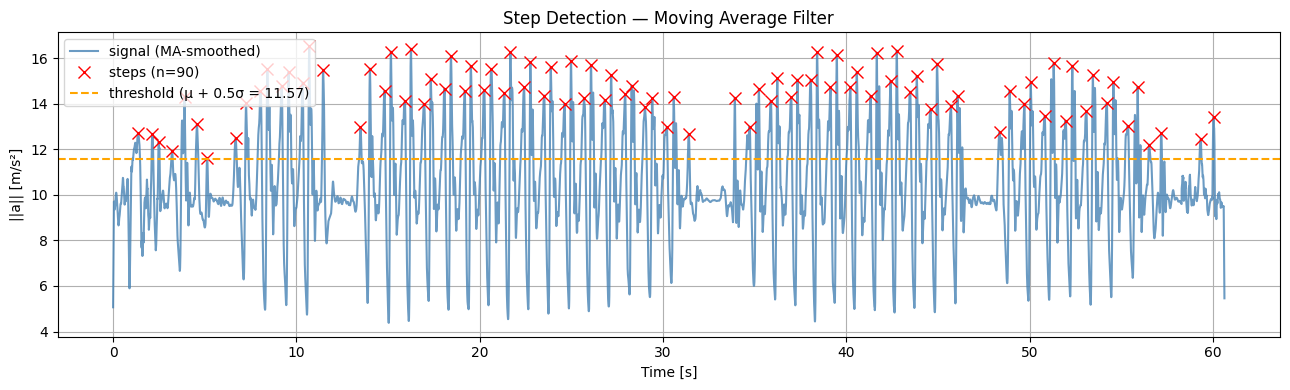

In [66]:
n = min(len(sig_time), len(sig_vals))

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(sig_time[:n], sig_vals[:n],
        alpha=0.8, color='steelblue', label='signal (MA-smoothed)')
ax.plot(step_times, sig_vals[peaks],
        'x', color='red', markersize=9, linewidth=2,
        label=f'steps (n={len(peaks)})')
ax.axhline(threshold, color='orange', linestyle='--',
           label=f'threshold (μ + {THRESHOLD_K}σ = {threshold:.2f})')
ax.set_title('Step Detection — Moving Average Filter')
ax.set_xlabel('Time [s]')
ax.set_ylabel('||a|| [m/s²]')
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()

steps_df = pd.DataFrame({
    "timestamp_ms": (sig_time[peaks] * 1000).astype("int64"),
    "accel_norm": sig_vals[peaks],
    "step_index": range(len(peaks)),
})

# Heading

In [67]:
mag_df["t_sec"] = (mag_df["timestamp_ms"] - mag_df["timestamp_ms"].min()) / 1000
accel_df["t_sec"] = (accel_df["timestamp_ms"] - accel_df["timestamp_ms"].min()) / 1000
gyro_df["t_sec"] = (gyro_df["timestamp_ms"] - gyro_df["timestamp_ms"].min()) / 1000
imu_processed_df["t_sec"] = (imu_processed_df["timestamp_ms"] - imu_processed_df["timestamp_ms"].min()) / 1000
steps_df["t_sec"] = (steps_df["timestamp_ms"] - steps_df["timestamp_ms"].min()) / 1000

## Integration der Gyro-Daten

Im ersten Schritt werden die drei Achsen des Gyro integriert um die Orientierung des Smartphones zu jedem Zeitpunkt zu erhalten. <br>
Der Gyro misst rad/s, also die Winkelgeschwindigkeit. Durch einfache Integration erhalten wir die Orientierung. Diese Messwerte unterliegen jedoch zufälligem Rauschen. Durch die Integration akkumuliert sich der Fehler, wir beobachten einen sogenannten Drift. Dieser muss später durch Fusion mit dem Magnetometer ausgeglichen werden.<br>

In [68]:
np.linalg.norm(accel_df[['x', 'y', 'z']].iloc[5].values)

def integrate_gyro(row):
    """
    Gyro measures the rotational velocity in rad/s. 
    integrate_gyro integrates the measured values into actual orientations in rad.
    :param row - One row of the dataframe containing at least the columns x, y, z and dt.
    :returns - The integrated orientations in rad.
    """
    return row[['x', 'y', 'z']] * row['dt']

def calculate_roll_pitch_yaw(df):
    """
    df contains the integrated orientation as euler orientation in the phones reference frame.
    calculate_roll_pitch_yaw converts the orientation into a world-frame orientation with roll, pitch and yaw values. 
    :param df - The dataframe containg the columns dx, dy and dz.
    :returns - The dataframe with columns roll, pitch and yaw applied.
    """
    omega = df[['dx', 'dy', 'dz']].copy().to_numpy(dtype=float) # Convert dataframe columns into a Nx3 matrix, N being the number or measurements.

    # Define initial Orientation
    orientation_current = R.identity()

    quaternions = np.zeros((len(omega), 4))   # Nx4 matrix representing the orientation as quaternions
    quaternions[0] = orientation_current.as_quat()

    # Iterate over each measurement (row) and continue conversion to quaternions
    for i in range(1, len(omega)):
        dq = R.from_rotvec(omega[i])

        orientation_current = orientation_current * dq

        quaternions[i] = orientation_current.as_quat()

    # Convert quaternions into roll, pitch and yaw
    euler_deg = R.from_quat(quaternions).as_euler('xyz', degrees=True)

    result = pd.DataFrame({
        'roll_deg': euler_deg[:, 0],
        'pitch_deg': euler_deg[:, 1],
        'yaw_deg': euler_deg[:, 2],
    })

    return result

gyro_df['dt'] = gyro_df['t_sec'].diff().fillna(0.0)
gyro_df[['dx', 'dy', 'dz']] = gyro_df.apply(integrate_gyro, axis=1)
gyro_df[['roll', 'pitch', 'yaw']] = calculate_roll_pitch_yaw(gyro_df)
gyro_df

NameError: name 'R' is not defined

In [ ]:
fig=go.Figure()

"""fig.add_trace(
    go.Scatter(
        x=df_processed['t_sec'],
        y=df_processed['x'],
        mode='lines',
        name='Yaw_fused'
    )
)"""

fig.add_trace(
    go.Scatter(
        x=gyro_df['t_sec'],
        y=gyro_df['yaw'],
        mode='lines',
        name='Yaw'
    )
)

markers_r1 = {4: 'H01', 11: 'H02', 32: 'T022', 46: 'H03'}
markers_r2 = {18: 'H03', 52: 'H13', 78: 'H12', 93: 'H11', 116: 'H01', 123: 'H02'}

for x, label in markers_r1.items():
    fig.add_vline(
        x=x,
        line_dash='dash',
        line_color='gray',
        annotation_text=label,
        annotation_position='top'
    )
    
fig.show()

KeyError: 'yaw'

In [ ]:
gyro_df['heading_rad'] = gyro_df.yaw / 180 * math.pi
gyro_df.head(5)

In [ ]:
#Sensorfusing aus Gyro und Mag
mag_df = pd.merge_asof(
    mag_df,
    gyro_df[['t_sec', 'heading_rad']],
    on='t_sec',
    direction='nearest'
)
mag_df

In [ ]:
def wrap(angle):
    return (angle + np.pi) % (2 * np.pi) - np.pi


def _yaw_free(orientation):
    """Yaw aus der Orientierung entfernen -> nur Roll/Pitch (zum Leveln des Mag)."""
    yaw = orientation.as_euler('ZYX')[0]
    return Rotation.from_euler('z', -yaw) * orientation


def prediction(x_k, p_k, u_k, dt, R):
    """
    Updates the system state and uncertainty by a measurement u_k.
    :param x_k: The current system state as scalar in rad.
    :param p_k: The current uncertainty as scalar.
    :param u_k: A sensor-measurement in [rad/s] representing the change in orientation.
    :param dt: The time difference since the last measurement.
    :param R: The covariance matrix representing the system noise.
    :returns The updated state x_k+1 and uncertainty p_k+1.
    """
    x_k = wrap(x_k + u_k * dt)
    p_k = p_k + R * dt
    return x_k, p_k


def update(x_k, p_k, z_k, Q):
    """
    Corrects the system state by a measurement input z_k.
    :param x_k: The current system state as scalar in rad.
    :param p_k: The current uncertainty as scalar.
    :param z_k: A sensor measurement representing the current orientation in rad.
    :param Q: The covariance matrix representing the measurement noise.
    :returns The updated state x_k+1 and uncertainty p_k+1.
    """
    kalman_gain = p_k / (p_k + Q)
    x_k = wrap(x_k + kalman_gain * wrap(z_k - x_k))
    p_k = (1 - kalman_gain) * p_k
    return x_k, p_k


def fuse_heading(df_gyro, df_mag, R=1e-3, Q=np.radians(15.0) ** 2):
    """
    Utilizes a simple kalman-filter to fuse the gyroscope- and magnetometer-readings.
    :param df_gyro: A dataframe representing the gyroscope readings. Contains at least following columns: [x, y, z, dt, t_sec].
    :param df_mag: A dataframe representing the magnetometer readings. Contains at least following columns: [x, y, z, t_sec].
    :param R: A scalar representing the system-noise.
    :param Q: A scalar representing the measurement-noise.
    """
    # Initialize gyro
    angular_velocity = df_gyro[['x', 'y', 'z']].to_numpy(float)
    time_gyro = df_gyro['t_sec'].to_numpy(float)
    time_step = np.diff(df_gyro.t_sec, prepend=0.0)#df_gyro['dt'].to_numpy(float)
    # Initialize magnetometer
    mag_field = df_mag[['x', 'y', 'z']].to_numpy(float)
    time_mag = df_mag['t_sec'].to_numpy(float)
    
    orientation = Rotation.identity()  # Initialize orientation
    heading = 0.0                      # Initial heading
    heading_variance = np.radians(180.0) ** 2
    heading_out = np.empty(len(time_gyro))
    mag_heading = np.full(len(time_mag), np.nan)
    mag_index = 0

    # Iterate over each gyro reading
    for i in range(len(time_gyro)):
        # Prediction-Step
        if i > 0:
            orientation = orientation * Rotation.from_rotvec(angular_velocity[i] * time_step[i])
            yaw_rate_world = orientation.apply(angular_velocity[i])[2]
            heading, heading_variance = prediction(
                heading, heading_variance, yaw_rate_world, time_step[i], R)
        # Update-Step
        while mag_index < len(time_mag) and time_mag[mag_index] <= time_gyro[i]:
            mag_leveled = _yaw_free(orientation).apply(mag_field[mag_index])
            measured_heading = -np.arctan2(mag_leveled[1], mag_leveled[0])   # CCW von magnetisch Nord
            mag_heading[mag_index] = measured_heading
            heading, heading_variance = update(
                heading, heading_variance, measured_heading, Q)
            mag_index += 1
        heading_out[i] = heading

    df_out = pd.DataFrame({'t_sec': time_gyro, 'heading_deg': np.degrees(heading_out)})
    df_mag_out = pd.DataFrame({'t_sec': time_mag, 'heading_mag_deg': np.degrees(mag_heading)})
    return df_out, df_mag_out

In [ ]:
np.diff(gyro_df.t_sec)
r0 = Rotation.from_euler('xyz', [0.0, 0.0, 0.0])

df_fused, df_mag_dbg = fuse_heading(
    gyro_df,
    mag_df
)

In [ ]:
fig=go.Figure()

"""fig.add_trace(
    go.Scatter(
        x=df_processed['t_sec'],
        y=df_processed['x'],
        mode='lines',
        name='Yaw_fused'
    )
)"""

fig.add_trace(
    go.Scatter(
        x=gyro_df['t_sec'],
        y=gyro_df['yaw'],
        mode='lines',
        name='Yaw raw',
    )
)

fig.add_trace(
    go.Scatter(
        x=df_fused['t_sec'],
        y=df_fused['heading_deg'],
        mode='lines',
        name='Yaw fused',
        line=dict(color="#ff0000")
    )
)

fig.add_trace(
    go.Scatter(
        x=df_mag_dbg['t_sec'],
        y=df_mag_dbg['heading_mag_deg'],
        mode='lines',
        name='Yaw mag',
        line=dict(color="#000000")
    )
)


markers_r1 = {4: 'H01', 11: 'H02', 32: 'T022', 46: 'H03'}
markers_r2 = {18: 'H03', 52: 'H13', 78: 'H12', 93: 'H11', 116: 'H01', 123: 'H02'}

for x, label in markers_r1.items():
    fig.add_vline(
        x=x,
        line_dash='dash',
        line_color='gray',
        annotation_text=label,
        annotation_position='top'
    )
    
for t in steps_df['t_sec']:
    fig.add_vline(
        x=t,
        line_color='rgba(255, 0, 0, 0.3)',
        line_width=1
    )
    
fig.show()

In [ ]:
df_gyro['heading_rad'] = df_fused.heading_deg / 180 * math.pi
#df_gyro['heading_rad'] = df_processed['x']  / 180 * math.pi
#df_gyro['heading_rad'] = heading_ip_deg  / 180 * math.pi

In [ ]:
heading_df = gyro_df[['timestamp_ms', 'heading_rad']].copy()
heading_df = heading_df[['run_id', 'timestamp_ms', 'heading_rad']].reset_index(drop=True)

KeyError: "['heading_rad'] not in index"

# RSSI Auswertung

In [69]:
RSSI_0           = -70.0  # dBm bei d=1m
PATH_LOSS_EXP    =   2.0  # Innenraum-Exponent
FLOOR_HEIGHT_M = 1.5  # dB Verlust pro Stockwerk
USE_OTHER_FLOOR = True  # True = andere Etagen mit Penalty, False = ignorieren
WINDOW_MS = 1000
PIXEL_TO_METER = 0.2

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True

print(f'RSSI-Messungen (gefiltert): {len(ble_df)}')
print(f'Beacon-Positionen geladen: {len(BEACON_DATA)}')
print(BEACON_DATA)
print(f'Groundtruth-Punkte (mit Koordinaten): {len(DOOR_POSITIONS)}')
print('Groundtruth:')
print(DOOR_POSITIONS)

RSSI-Messungen (gefiltert): 515
Beacon-Positionen geladen: 6
[('arrive_emi1', 370.0, 47.0, 1), ('arrive_emi2', 445.0, 40.0, 1), ('arrive_emi3', 588.0, 20.0, 1), ('arrive_emi4', 590.0, 20.0, 0), ('arrive_emi8', 370.0, 50.0, 0), ('arrive_emi10', 510.0, 40.0, 0)]
Groundtruth-Punkte (mit Koordinaten): 11
Groundtruth:
[('H01', 600, 60, 0), ('H02', 587, 31, 0), ('H03', 396, 30, 0), ('T016', 626, 17, 0), ('T021', 508, 22, 0), ('T022', 475, 22, 0), ('H11', 600, 60, 1), ('H12', 587, 31, 1), ('H13', 396, 30, 1), ('T109c', 480, 40, 1), ('T125', 325, 33, 1)]


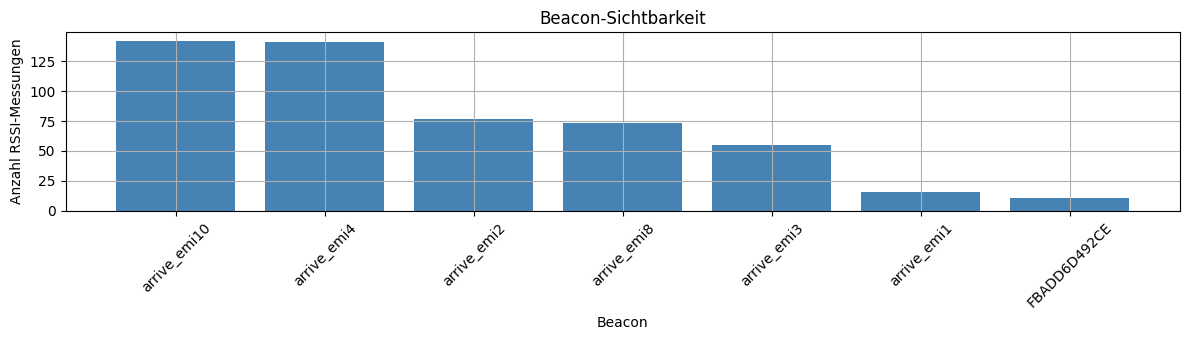

In [70]:
visibility = (
    ble_df.groupby("beacon_name")
    .size()
    .reset_index(name="n_measurements")
    .sort_values("n_measurements", ascending=False)
)

fig, ax = plt.subplots(figsize=(12, 3.5))
ax.bar(
    visibility["beacon_name"],
    visibility["n_measurements"],
    color="steelblue",
)
ax.set_title("Beacon-Sichtbarkeit")
ax.set_xlabel("Beacon")
ax.set_ylabel("Anzahl RSSI-Messungen")
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

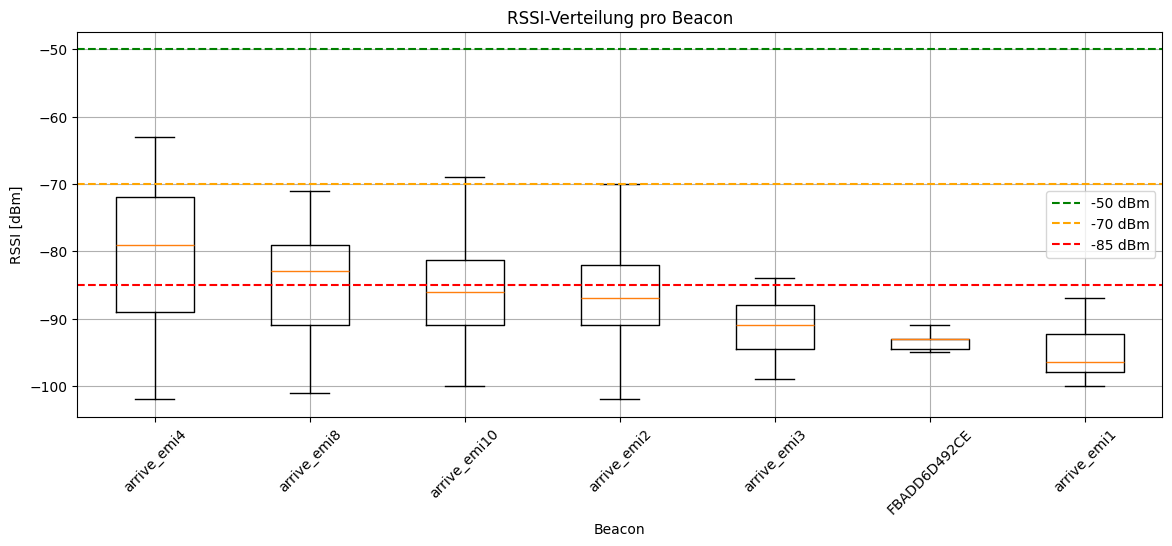

In [71]:
beacon_order = (
    ble_df.groupby("beacon_name")["rssi"]
    .median()
    .sort_values(ascending=False)
    .index
)

data = [
    ble_df.loc[ble_df["beacon_name"] == beacon_id, "rssi"].dropna()
    for beacon_id in beacon_order
]

plt.figure(figsize=(14, 5))
plt.boxplot(data, tick_labels=beacon_order, showfliers=False)

plt.axhline(-50, color="green", linestyle="--", label="-50 dBm")
plt.axhline(-70, color="orange", linestyle="--", label="-70 dBm")
plt.axhline(-85, color="red", linestyle="--", label="-85 dBm")

plt.title("RSSI-Verteilung pro Beacon")
plt.xlabel("Beacon")
plt.ylabel("RSSI [dBm]")
plt.xticks(rotation=45)
plt.legend()
plt.show()

In [73]:
# Stockwerk bestimmen
eg_beacons = [b for b, _, _, f in BEACON_DATA if f == 0]
og_beacons = [b for b, _, _, f in BEACON_DATA if f == 1]
print(f'EG-Beacons ({len(eg_beacons)}): {eg_beacons}')
print(f'OG-Beacons ({len(og_beacons)}): {og_beacons}')

def estimate_floor(rssi_window: pd.DataFrame) -> int:
    """Heuristik: Stärkere mittlere RSSI = wahrscheinlich selbes Stockwerk."""
    rssi_eg = rssi_window[rssi_window['beacon_name'].isin(eg_beacons)]['rssi'].mean()
    rssi_og = rssi_window[rssi_window['beacon_name'].isin(og_beacons)]['rssi'].mean()

    if pd.isna(rssi_eg) and pd.isna(rssi_og):
        return -1  # keine Beacons sichtbar

    # NaN als -inf behandeln → das andere Stockwerk gewinnt automatisch
    rssi_eg = rssi_eg if not pd.isna(rssi_eg) else float("-inf")
    rssi_og = rssi_og if not pd.isna(rssi_og) else float("-inf")

    return 0 if rssi_eg >= rssi_og else 1

EG-Beacons (3): ['arrive_emi4', 'arrive_emi8', 'arrive_emi10']
OG-Beacons (3): ['arrive_emi1', 'arrive_emi2', 'arrive_emi3']


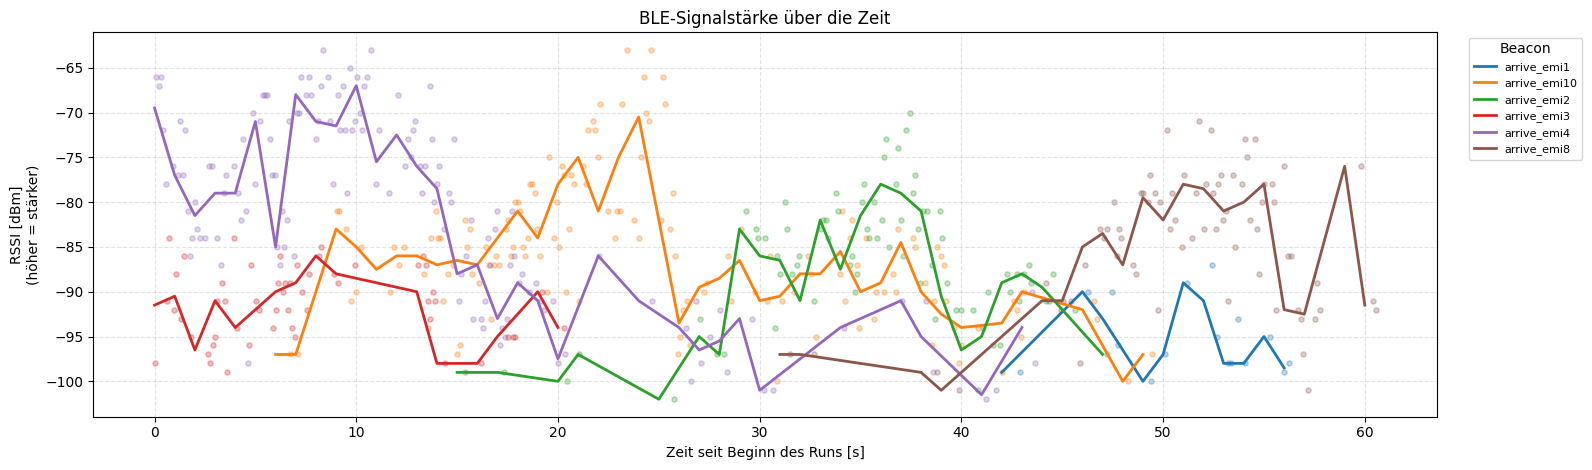

In [74]:
beacon_names = [b for b, *_ in BEACON_DATA]

plot_data = ble_df.loc[
    ble_df["beacon_name"].isin(beacon_names),
    ["timestamp_ms", "beacon_name", "rssi"]
].copy()

plot_data["time_s"] = (
    plot_data["timestamp_ms"] - plot_data["timestamp_ms"].min()
) / WINDOW_MS

plot_data = plot_data.sort_values("timestamp_ms")

fig, ax = plt.subplots(figsize=(16, 4.8))

for beacon_name, group in plot_data.groupby("beacon_name", sort=True):
    ax.scatter(
        group["time_s"],
        group["rssi"],
        s=14,
        alpha=0.30
    )

    smooth = (
        group.assign(time_bin=group["time_s"].astype(int))
        .groupby("time_bin", as_index=False)["rssi"]
        .median()
    )

    ax.plot(
        smooth["time_bin"],
        smooth["rssi"],
        linewidth=2,
        label=beacon_name
    )

ax.set_title("BLE-Signalstärke über die Zeit")
ax.set_xlabel("Zeit seit Beginn des Runs [s]")
ax.set_ylabel("RSSI [dBm]\n(höher = stärker)")
ax.grid(True, linestyle="--", alpha=0.35)
ax.legend(
    title="Beacon",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    fontsize=8
)

fig.tight_layout()
plt.show()

In [76]:
from datetime import datetime
from zoneinfo import ZoneInfo

def datetime_to_timestamp_ms(datetime_str: str) -> int:
    local_dt = datetime.strptime(datetime_str, "%Y-%m-%d %H:%M:%S").replace(
        tzinfo=ZoneInfo("Europe/Berlin")
    )
    return int(local_dt.timestamp() * 1000)

GROUNDTRUTH_INPUT = [
    ("R1", "H01", "2026-06-16 14:16:04"),
    ("R1", "H02", "2026-06-16 14:16:11"),
    ("R1", "T022", "2026-06-16 14:16:32"),
    ("R1", "H03", "2026-06-16 14:16:46"),
    ("R2", "H03", "2026-06-16 15:02:18"),
    ("R2", "H13", "2026-06-16 15:02:52"),
    ("R2", "H12", "2026-06-16 15:03:18"),
    ("R2", "H11", "2026-06-16 15:03:33"),
    ("R2", "H01", "2026-06-16 15:03:56"),
    ("R2", "H02", "2026-06-16 15:04:03"),
    ("R3", "T125", "2026-06-16 15:08:05"),
    ("R3", "H13", "2026-06-16 15:08:16"),
    ("R3", "T109c", "2026-06-16 15:08:40"),
    ("R3", "H12", "2026-06-16 15:09:10"),
    ("R3", "H11", "2026-06-16 15:09:28"),
    ("R3", "H01", "2026-06-16 15:09:49"),
    ("R3", "T016", "2026-06-16 15:10:07"),
    ("R3", "H02", "2026-06-16 15:10:18"),
    ("R3", "T021", "2026-06-16 15:10:38"),
    ("R3", "H03", "2026-06-16 15:11:09"),
]

gt_df = pd.DataFrame(
    [(run_id, tuer_id, datetime_to_timestamp_ms(ts))
     for run_id, tuer_id, ts in GROUNDTRUTH_INPUT if run_id == "R1"],
    columns=["run_id", "tuer_id", "timestamp_ms"]
)[["tuer_id", "timestamp_ms"]]

groundtruth_plot = gt_df.sort_values("timestamp_ms").copy()
groundtruth_plot["time_s"] = (groundtruth_plot["timestamp_ms"] - ble_df["timestamp_ms"].min()) / WINDOW_MS

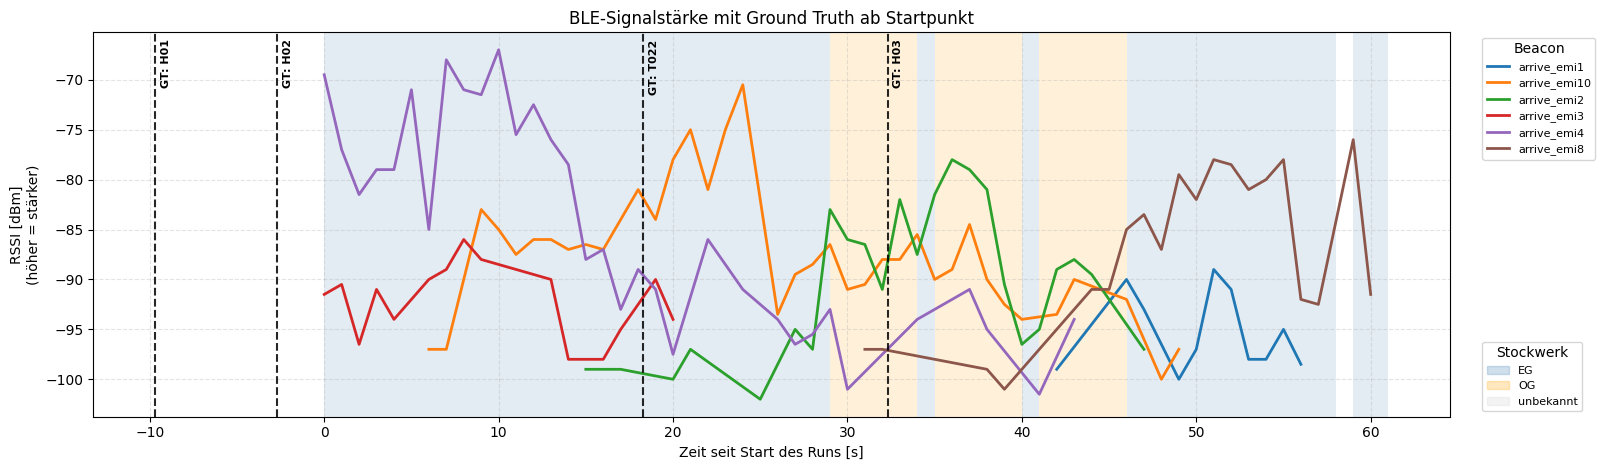

In [77]:
# 1. BLE-Daten vorbereiten
plot_data = ble_df.loc[
    ble_df["beacon_name"].isin(beacon_names),
    ["timestamp_ms", "beacon_name", "rssi"]
].sort_values("timestamp_ms").copy()
plot_data["time_s"] = (plot_data["timestamp_ms"] - plot_data["timestamp_ms"].min()) / WINDOW_MS

# 3. Stockwerk-Farben & Legende
floor_colors  = {0: "steelblue", 1: "orange", -1: "lightgray"}
floor_labels  = {0: "EG", 1: "OG", -1: "unbekannt"}
floor_patches = [mpatches.Patch(color=floor_colors[f], alpha=0.25, label=floor_labels[f]) for f in [0, 1, -1]]

# 4. Timeline
fig, ax = plt.subplots(figsize=(16, 4.8))

ble_df["time_bin"] = ((ble_df["timestamp_ms"] - ble_df["timestamp_ms"].min()) / WINDOW_MS).astype(int)
for t_bin, window in ble_df.groupby("time_bin"):
    floor = estimate_floor(window)
    ax.axvspan(t_bin, t_bin + 1, color=floor_colors[floor], alpha=0.15, zorder=0, linewidth=0)

for beacon_name, group in plot_data.groupby("beacon_name", sort=True):
    smooth = group.assign(time_bin=group["time_s"].astype(int)).groupby("time_bin", as_index=False)["rssi"].median()
    ax.plot(smooth["time_bin"], smooth["rssi"], linewidth=2, label=beacon_name)

for _, gt in groundtruth_plot.iterrows():
    ax.axvline(gt["time_s"], color="black", linestyle="--", linewidth=1.5, alpha=0.85, zorder=10)
    ax.annotate(
        f"GT: {gt['tuer_id']}", xy=(gt["time_s"], 1), xycoords=("data", "axes fraction"),
        xytext=(4, -5), textcoords="offset points", rotation=90, va="top", ha="left",
        fontsize=8, color="black", fontweight="bold", zorder=11
    )

ax.set_title("BLE-Signalstärke mit Ground Truth ab Startpunkt")
ax.set_xlabel("Zeit seit Start des Runs [s]")
ax.set_ylabel("RSSI [dBm]\n(höher = stärker)")
ax.grid(True, linestyle="--", alpha=0.35)

beacon_legend = ax.legend(title="Beacon", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
ax.add_artist(beacon_legend)
ax.legend(handles=floor_patches, title="Stockwerk", bbox_to_anchor=(1.02, 0), loc="lower left", fontsize=8)

fig.tight_layout()
plt.show()

In [79]:
# Log-Distance Path Loss

def rssi_to_distance(rssi: float, floor_delta: int = 0) -> float:
    """
    Inverse Log-Distance Path Loss mit additivem Floor-Aufschlag.
    floor_delta=0 → gleiche Etage
    floor_delta>0 → +FLOOR_HEIGHT_M pro Etage wird addiert
    """
    if floor_delta != 0 and not USE_OTHER_FLOOR:
        return np.nan

    base_dist = 10.0 ** ((RSSI_0 - rssi) / (10.0 * PATH_LOSS_EXP))

    if floor_delta == 0:
        return base_dist

    # Fester Aufschlag pro Etage – unabhängig von base_dist
    return base_dist + abs(floor_delta) * FLOOR_HEIGHT_M


# ── Anwenden ────────────────────────────────────────────────────────
ble_df['beacon_floor'] = ble_df['beacon_name'].map(
    lambda b: next((f for n, x, y, f in BEACON_DATA if n == b), 0)
)
ble_df['floor_delta'] = ble_df['beacon_floor'].fillna(0).astype(int)
ble_df['dist_est_m']  = ble_df.apply(
    lambda r: rssi_to_distance(r['rssi'], r['floor_delta']), axis=1
)

# Andere Etagen rausfiltern (wenn USE_OTHER_FLOOR=False)
rssi_df_clean = ble_df.dropna(subset=['dist_est_m'])

print('Distanzschätzungen (Beispiel):')
print(rssi_df_clean[['beacon_name','rssi','floor_delta','dist_est_m']].head(10).round(2))

Distanzschätzungen (Beispiel):
     beacon_name  rssi  floor_delta  dist_est_m
31   arrive_emi3 -98.0            1       26.62
93   arrive_emi4 -66.0            0        0.63
183  arrive_emi4 -67.0            0        0.71
275  arrive_emi4 -66.0            0        0.63
369  arrive_emi4 -72.0            0        1.26
459  arrive_emi4 -78.0            0        2.51
491  arrive_emi3 -91.0            1       12.72
585  arrive_emi3 -84.0            1        6.51
737  arrive_emi4 -76.0            0        2.00
769  arrive_emi3 -92.0            1       14.09


In [82]:
# Positions Wahrscheinlichkeit KDE und multilateration 
#TODO erklären!!

BEACON_POS_DICT = {name: (x, y) for name, x, y, floor in BEACON_DATA}
BEACON_FLOOR_MAP = {name: floor for name, x, y, floor in BEACON_DATA}

def rssi_likelihood(positions, positions_floor, rssi_measurements, beacon_pos_dict=BEACON_POS_DICT,
                     beacon_floor_dict=None, sigma=2.0):
    """
    positions: np.array shape (N, 2) — Grid-Punkte ODER Partikel
    positions_floor: int oder np.array shape (N,) — Stockwerk der Position(en)
    rssi_measurements: dict {beacon_name: rssi_value}
    beacon_floor_dict: dict {beacon_name: floor} — Stockwerk je Beacon
    """
    positions = np.atleast_2d(positions)
    n = len(positions)
    positions_floor = np.full(n, positions_floor) if np.isscalar(positions_floor) else positions_floor

    log_likelihood = np.zeros(n)

    for beacon_name, rssi in rssi_measurements.items():
        if beacon_name not in beacon_pos_dict:
            continue
        bx, by = beacon_pos_dict[beacon_name]
        beacon_floor = beacon_floor_dict.get(beacon_name, 0) if beacon_floor_dict else 0

        for floor_delta in np.unique(positions_floor - beacon_floor):
            mask = (positions_floor - beacon_floor) == floor_delta
            dist_measured = rssi_to_distance(rssi, floor_delta=int(floor_delta))
            if np.isnan(dist_measured):
                log_likelihood[mask] = -np.inf
                continue

            dist_to_positions = np.sqrt(
                (positions[mask, 0] - bx) ** 2 + (positions[mask, 1] - by) ** 2
            )
            log_likelihood[mask] += -0.5 * ((dist_to_positions - dist_measured) / sigma) ** 2

    max_ll = log_likelihood[np.isfinite(log_likelihood)].max() if np.isfinite(log_likelihood).any() else 0
    return np.exp(log_likelihood - max_ll)

Keine ausreichenden RSSI-Werte für H01 @ 1781612164000
Keine ausreichenden RSSI-Werte für H02 @ 1781612171000


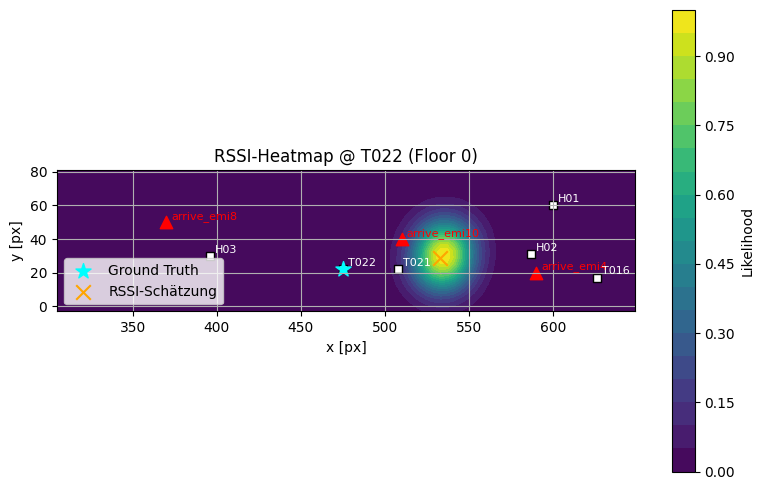

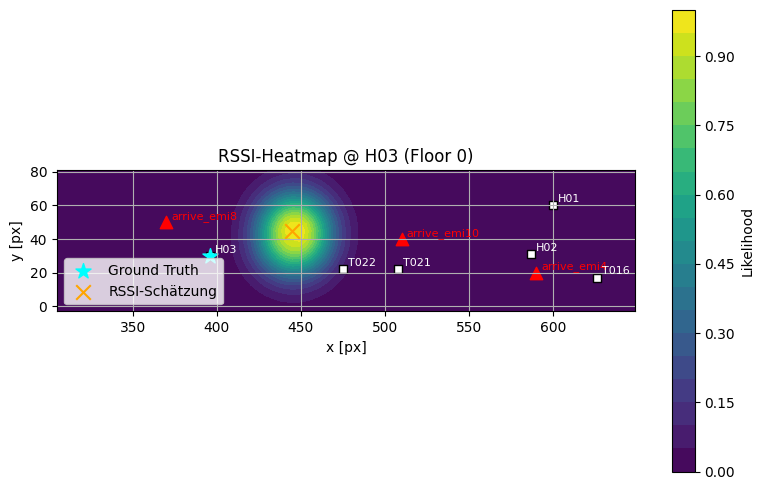

In [84]:
# RSSI-Heatmap pro Ground-Truth-Zeitpunkt

DOOR_POS_DICT = {name: (x, y) for name, x, y, floor in DOOR_POSITIONS}
DOOR_FLOOR_DICT = {name: floor for name, x, y, floor in DOOR_POSITIONS}

# Grundrissgrenzen aus Beacon- und Door-Positionen
all_x = [x for _, x, _, _ in BEACON_DATA] + [x for _, x, _, _ in DOOR_POSITIONS]
all_y = [y for _, _, y, _ in BEACON_DATA] + [y for _, _, y, _ in DOOR_POSITIONS]

x_min, x_max = min(all_x) - 20, max(all_x) + 20
y_min, y_max = min(all_y) - 20, max(all_y) + 20

GRID_RES = 4  # Pixel
x_grid = np.arange(x_min, x_max + GRID_RES, GRID_RES)
y_grid = np.arange(y_min, y_max + GRID_RES, GRID_RES)
X, Y = np.meshgrid(x_grid, y_grid)
grid_positions = np.column_stack([X.ravel(), Y.ravel()])


def get_rssi_window(center_ts, window_ms=2000, min_beacons=2):
    w = ble_df[
        (ble_df["timestamp_ms"] >= center_ts - window_ms // 2) &
        (ble_df["timestamp_ms"] <= center_ts + window_ms // 2)
    ].copy()

    if w.empty:
        return {}

    rssi_measurements = (
        w.groupby("beacon_name")["rssi"]
        .median()
        .dropna()
        .to_dict()
    )

    if len(rssi_measurements) < min_beacons:
        return {}

    return rssi_measurements


def estimate_position_from_rssi(rssi_measurements, floor_hint=0):
    if len(rssi_measurements) == 0:
        return np.nan, np.nan, np.nan

    Z = rssi_likelihood(
        positions=grid_positions,
        positions_floor=floor_hint,
        rssi_measurements=rssi_measurements,
        beacon_pos_dict=BEACON_POS_DICT,
        beacon_floor_dict=BEACON_FLOOR_MAP,
        sigma=25.0
    ).reshape(X.shape)

    max_idx = np.unravel_index(np.argmax(Z), Z.shape)
    x_hat = X[max_idx]
    y_hat = Y[max_idx]
    score = Z[max_idx]

    return x_hat, y_hat, score


# Heatmaps für alle GT-Punkte
for _, gt in gt_df.iterrows():
    tuer_id = gt["tuer_id"]
    ts = gt["timestamp_ms"]

    gt_x, gt_y = DOOR_POS_DICT[tuer_id]
    gt_floor = DOOR_FLOOR_DICT[tuer_id]

    rssi_measurements = get_rssi_window(ts, window_ms=2000, min_beacons=2)
    if len(rssi_measurements) == 0:
        print(f"Keine ausreichenden RSSI-Werte für {tuer_id} @ {ts}")
        continue

    Z = rssi_likelihood(
        positions=grid_positions,
        positions_floor=gt_floor,
        rssi_measurements=rssi_measurements,
        beacon_pos_dict=BEACON_POS_DICT,
        beacon_floor_dict=BEACON_FLOOR_MAP,
        sigma=25.0
    ).reshape(X.shape)

    x_hat, y_hat, score = estimate_position_from_rssi(rssi_measurements, floor_hint=gt_floor)

    fig, ax = plt.subplots(figsize=(8, 5))
    hm = ax.contourf(X, Y, Z, levels=20, cmap="viridis")
    plt.colorbar(hm, ax=ax, label="Likelihood")

    for b_name, bx, by, bf in BEACON_DATA:
        if bf == gt_floor:
            ax.scatter(bx, by, c="red", s=80, marker="^")
            ax.text(bx + 3, by + 2, b_name, fontsize=8, color="red")

    same_floor_doors = [(n, x, y) for n, x, y, f in DOOR_POSITIONS if f == gt_floor]
    for d_name, dx, dy in same_floor_doors:
        ax.scatter(dx, dy, c="white", s=35, edgecolor="black", marker="s")
        ax.text(dx + 3, dy + 2, d_name, fontsize=8, color="white")

    ax.scatter(gt_x, gt_y, c="cyan", s=130, marker="*", label="Ground Truth")
    ax.scatter(x_hat, y_hat, c="orange", s=110, marker="x", label="RSSI-Schätzung")

    ax.set_title(f"RSSI-Heatmap @ {tuer_id} (Floor {gt_floor})")
    ax.set_xlabel("x [px]")
    ax.set_ylabel("y [px]")
    ax.legend()
    ax.set_aspect("equal")
    plt.tight_layout()
    plt.show()

In [85]:
# Fehleranalyse RSSI -> Position

results = []

for _, gt in gt_df.iterrows():
    tuer_id = gt["tuer_id"]
    ts = gt["timestamp_ms"]

    gt_x, gt_y = DOOR_POS_DICT[tuer_id]
    gt_floor = DOOR_FLOOR_DICT[tuer_id]

    rssi_measurements = get_rssi_window(ts, window_ms=2000, min_beacons=2)
    if len(rssi_measurements) == 0:
        results.append({
            "tuer_id": tuer_id,
            "timestamp_ms": ts,
            "gt_x": gt_x,
            "gt_y": gt_y,
            "gt_floor": gt_floor,
            "pred_x": np.nan,
            "pred_y": np.nan,
            "pred_floor": np.nan,
            "score": np.nan,
            "error_px": np.nan,
            "error_m": np.nan,
            "nearest_door_pred": None,
            "door_match": False,
            "floor_match": False,
            "n_beacons": 0
        })
        continue

    pred_floor = estimate_floor(
        ble_df[
            (ble_df["timestamp_ms"] >= ts - 1000) &
            (ble_df["timestamp_ms"] <= ts + 1000)
        ]
    )

    x_hat, y_hat, score = estimate_position_from_rssi(
        rssi_measurements=rssi_measurements,
        floor_hint=gt_floor
    )

    error_px = np.sqrt((x_hat - gt_x) ** 2 + (y_hat - gt_y) ** 2)
    error_m = error_px * PIXEL_TO_METER

    same_floor_doors = pd.DataFrame(
        [(n, x, y) for n, x, y, f in DOOR_POSITIONS if f == gt_floor],
        columns=["door", "x", "y"]
    )
    same_floor_doors["dist_px"] = np.sqrt((same_floor_doors["x"] - x_hat) ** 2 + (same_floor_doors["y"] - y_hat) ** 2)
    nearest_door_pred = same_floor_doors.sort_values("dist_px").iloc[0]["door"]

    results.append({
        "tuer_id": tuer_id,
        "timestamp_ms": ts,
        "gt_x": gt_x,
        "gt_y": gt_y,
        "gt_floor": gt_floor,
        "pred_x": x_hat,
        "pred_y": y_hat,
        "pred_floor": pred_floor,
        "score": score,
        "error_px": error_px,
        "error_m": error_m,
        "nearest_door_pred": nearest_door_pred,
        "door_match": nearest_door_pred == tuer_id,
        "floor_match": pred_floor == gt_floor,
        "n_beacons": len(rssi_measurements)
    })

results_df = pd.DataFrame(results)
display(results_df)

,tuer_id,timestamp_ms,gt_x,gt_y,gt_floor,pred_x,pred_y,pred_floor,score,error_px,error_m,nearest_door_pred,door_match,floor_match,n_beacons
0,H01,1781612164000,600,60,0,NaN,NaN,NaN,NaN,NaN,NaN,None,False,False,0
1,H02,1781612171000,587,31,0,NaN,NaN,NaN,NaN,NaN,NaN,None,False,False,0
2,T022,1781612192000,475,22,0,533.0,29.0,0.0,1.0,58.420887,11.684177,T021,False,True,4
3,H03,1781612206000,396,30,0,445.0,45.0,1.0,1.0,51.244512,10.248902,T022,False,False,3


In [86]:
valid = results_df.dropna(subset=["error_px"]).copy()

metrics = {
    "n_valid": len(valid),
    "MAE_px": valid["error_px"].mean(),
    "RMSE_px": np.sqrt(np.mean(valid["error_px"] ** 2)),
    "Median_px": valid["error_px"].median(),
    "MAE_m": valid["error_m"].mean(),
    "RMSE_m": np.sqrt(np.mean(valid["error_m"] ** 2)),
    "Median_m": valid["error_m"].median(),
    "Floor_Accuracy": valid["floor_match"].mean(),
    "Door_Accuracy": valid["door_match"].mean(),
}

metrics_df = pd.DataFrame([metrics])
display(metrics_df.round(3))

,n_valid,MAE_px,RMSE_px,Median_px,MAE_m,RMSE_m,Median_m,Floor_Accuracy,Door_Accuracy
0,2,54.833,54.95,54.833,10.967,10.99,10.967,0.5,0.0


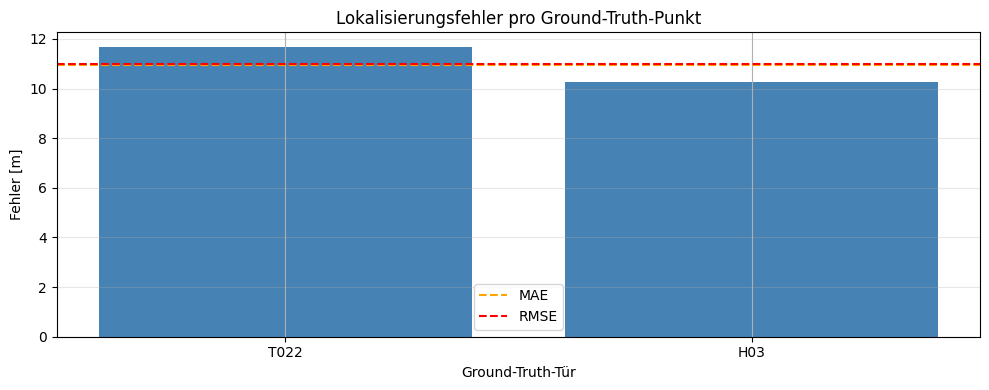

In [87]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(valid["tuer_id"], valid["error_m"], color="steelblue")
ax.axhline(valid["error_m"].mean(), color="orange", linestyle="--", label="MAE")
ax.axhline(np.sqrt(np.mean(valid["error_m"] ** 2)), color="red", linestyle="--", label="RMSE")
ax.set_title("Lokalisierungsfehler pro Ground-Truth-Punkt")
ax.set_xlabel("Ground-Truth-Tür")
ax.set_ylabel("Fehler [m]")
ax.legend()
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# Particle Filter